# Titanic Survival Prediction 🚢

## Introduction

In [53]:
import pandas as pd      #explored and readed the file using the pandas 

df = pd.read_csv("titanic.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [54]:
df.info()    #Dataset structure

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [55]:
df.describe()    #Statistics

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [56]:
df.isnull().sum()      #df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

After running those commands, you should understand:

✔ How many passengers are in the dataset
✔ What each column represents
✔ Which columns contain missing data
✔ Basic statistics of the dataset

In [57]:
#Load the Clean Dataset
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("titanic_cleaned.csv")

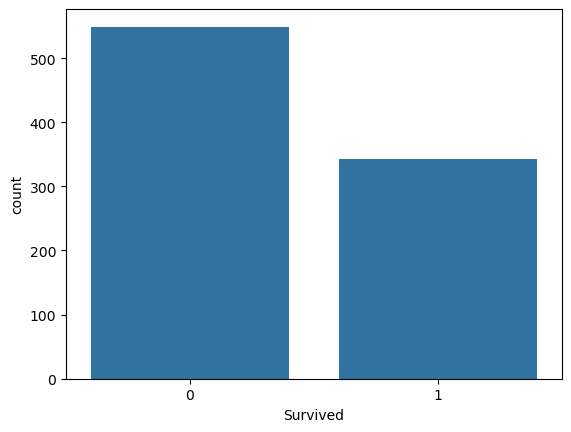

In [58]:
#SURVIVAL COUNT 
sns.countplot(x='Survived', data=df)
plt.show()

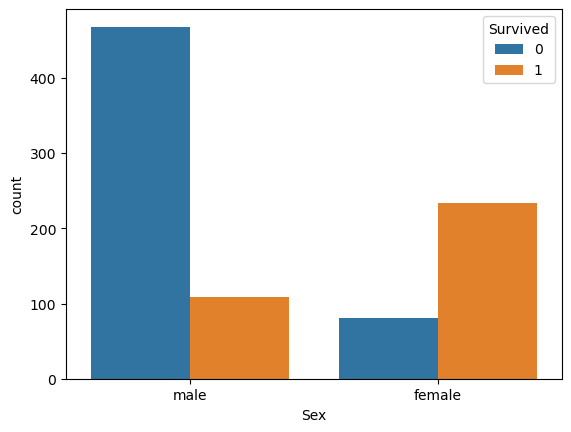

In [59]:
#survival by gender 
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

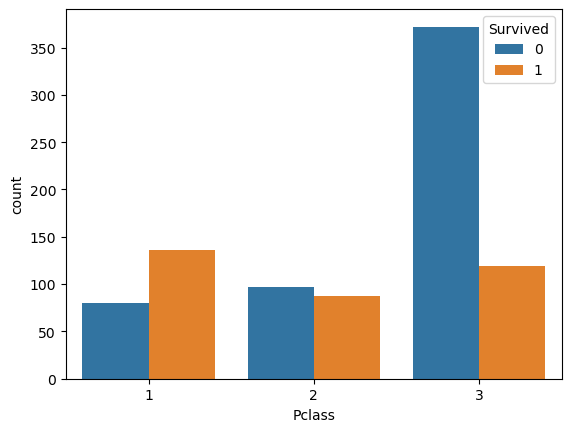

In [60]:
#Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

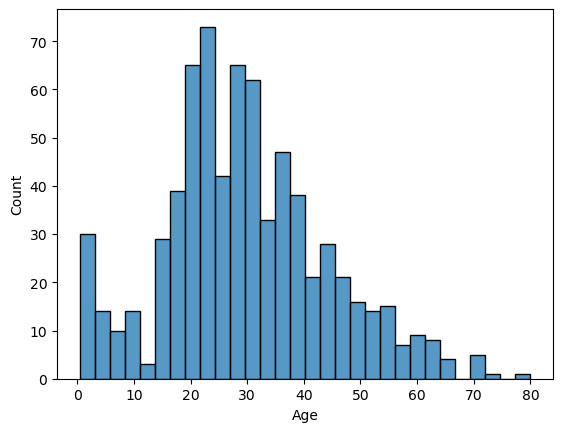

In [61]:
#Age Distribution
sns.histplot(df['Age'], bins=30)
plt.show()

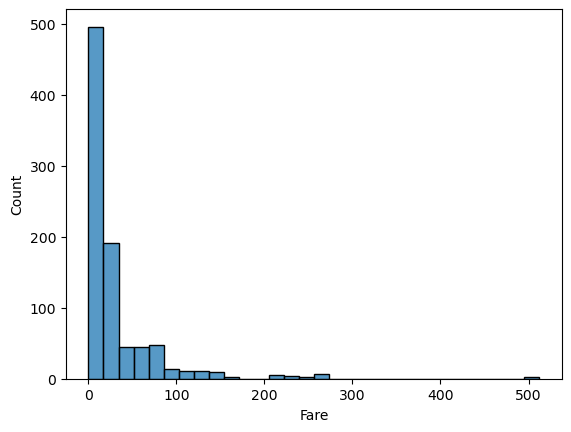

In [62]:
#Fare Distribution
sns.histplot(df['Fare'], bins=30)
plt.show()

Day 3 Observations

1. Women had higher survival rates.
2. First-class passengers survived more.
3. Most passengers were between 20–40 years old.
4. Many passengers paid low ticket fares.

                                           DAY  4

In [63]:
#Separate Features and Target
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [64]:
df = df.drop(["Name", "Ticket", "Cabin"], axis=1, errors="ignore")

In [65]:
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch',
       'Fare', 'Embarked'],
      dtype='object')

In [66]:
df = df.drop(columns=["Name","Ticket"], errors="ignore")

In [67]:
df["Sex"] = df["Sex"].map({"male":0, "female":1})

In [68]:
#Separate features and target
X = df.drop("Survived", axis=1)
y = df["Survived"]

In [69]:
#Split the dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
#Check accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

In [72]:
'''
this accuracy is so low then expected so we are will fix two common issues
1.Remove PassengerId
2.Retrain the Model'''

'\nthis accuracy is so low then expected so we are will fix two common issues\n1.Remove PassengerId\n2.Retrain the Model'

In [ ]:
df = df.drop("PassengerId", axis=1)

In [ ]:
# Remove unnecessary column (if it exists)
df = df.drop("PassengerId", axis=1, errors="ignore")

#  Separate features (X) and target (y)
X = df.drop("Survived", axis=1)
y = df["Survived"]

#  Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#  Train the model
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

#  Make predictions
predictions = model.predict(X_test)

#  Check the accuracy of the model
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Random Forest Accuracy: 0.8100558659217877

Feature Importance:
      Feature  Importance
1         Sex    0.416989
5        Fare    0.196999
0      Pclass    0.130753
2         Age    0.130689
3       SibSp    0.053312
4       Parch    0.038112
7  Embarked_S    0.022934
6  Embarked_Q    0.010212


C:\Users\manth\AppData\Local\Temp\ipykernel_12168\1411856261.py:76: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")


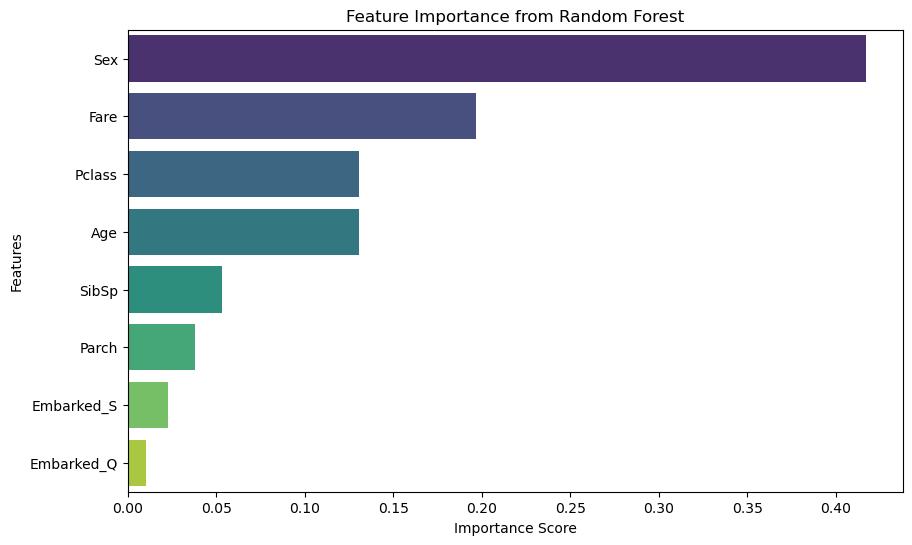

In [89]:
# -----------------------------
# Day 7: Random Forest Model Training & Feature Importance
# -----------------------------

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv("titanic.csv")

# -----------------------------
# Data Cleaning
# -----------------------------
# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop unnecessary string columns
df = df.drop(["Name", "Ticket", "Cabin", "PassengerId"], axis=1, errors="ignore")

# Convert categorical columns to numeric
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# -----------------------------
# Features and Target
# -----------------------------
X = df.drop("Survived", axis=1)
y = df["Survived"]

# -----------------------------
# Train-Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Train Random Forest Model
# -----------------------------
model = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42)
model.fit(X_train, y_train)

# -----------------------------
# Make Predictions
# -----------------------------
predictions = model.predict(X_test)

# -----------------------------
# Evaluate Accuracy
# -----------------------------
accuracy = accuracy_score(y_test, predictions)
print("Random Forest Accuracy:", accuracy)

# -----------------------------
# Feature Importance
# -----------------------------
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(feature_importance)

# -----------------------------
# Feature Importance Visualization
# -----------------------------
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()


ML Accuracy Improvement Challenge

In [74]:
print(df.isnull().sum())   #Check for missing values

PassengerId      0
Survived         0
Pclass           0
Sex              0
Age            177
SibSp            0
Parch            0
Fare             0
Embarked         0
dtype: int64


In [75]:
df = df.dropna()    #Handle missing values

In [76]:
df = df.drop(["PassengerId"], axis=1, errors="ignore") # Remove unnecessary columns

In [77]:
X = df.drop("Survived", axis=1)
y = df["Survived"]   #Split features and target

In [78]:
#--------------------------------------improvement in day 4 model dicision tree------------------
# Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("titanic.csv")

# -----------------------------
# DATA CLEANING
# -----------------------------

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Convert categorical data to numbers
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Convert Embarked into dummy variables
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Remove unnecessary columns
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1, errors="ignore")

# -----------------------------
# FEATURE / TARGET SPLIT
# -----------------------------

X = df.drop("Survived", axis=1)
y = df["Survived"]

# -----------------------------
# TRAIN TEST SPLIT
# -----------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# TRAIN MODEL
# -----------------------------

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

# -----------------------------
# PREDICTION
# -----------------------------

predictions = model.predict(X_test)

# -----------------------------
# ACCURACY
# -----------------------------

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.7821229050279329


In [79]:
# now we will train the model in random forest 
# -----------------------------
# Import Libraries
# -----------------------------
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# -----------------------------
# Load Dataset
# -----------------------------
df = pd.read_csv("titanic.csv")

# -----------------------------
# Data Cleaning
# -----------------------------

# Fill missing values
df["Age"] = df["Age"].fillna(df["Age"].mean())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Convert categorical values
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# Convert Embarked to dummy variables
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Remove unnecessary columns
df = df.drop(["PassengerId","Name","Ticket","Cabin"], axis=1, errors="ignore")

# -----------------------------
# Split Features and Target
# -----------------------------
X = df.drop("Survived", axis=1)
y = df["Survived"]

# -----------------------------
# Train Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# Train Random Forest Model
# -----------------------------
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

# -----------------------------
# Make Predictions
# -----------------------------
predictions = model.predict(X_test)

# -----------------------------
# Evaluate Model
# -----------------------------
accuracy = accuracy_score(y_test, predictions)

print("Random Forest Accuracy:", accuracy)

# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

Random Forest Accuracy: 0.8156424581005587

Feature Importance:
      Feature  Importance
5        Fare    0.281155
1         Sex    0.263743
2         Age    0.256274
0      Pclass    0.075703
3       SibSp    0.051289
4       Parch    0.038749
7  Embarked_S    0.023923
6  Embarked_Q    0.009166


                                        DAY 6

Step 1 — Feature Engineering
We will create a new feature called FamilySize.

Reason:
Passengers traveling with family sometimes had better survival chances.

In [80]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
#Now the model understands group size on the ship.

Step 2 — Train Improved Model

We now retrain the Random Forest with better parameters

In [81]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)
#This helps reduce overfitting

RandomForestClassifier(max_depth=6, n_estimators=200, random_state=42)

Step 3 — Make Predictions

In [82]:
#The model predicts survival for new unseen passenger
predictions = model.predict(X_test)

Step 4 — Check Accuracy

In [83]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, predictions)

print("Improved Model Accuracy:", accuracy)

Improved Model Accuracy: 0.8100558659217877


In [84]:
import pandas as pd

feature_importance = pd.Series(model.feature_importances_, index=X_train.columns)
feature_importance.sort_values(ascending=False)

Sex           0.416989
Fare          0.196999
Pclass        0.130753
Age           0.130689
SibSp         0.053312
Parch         0.038112
Embarked_S    0.022934
Embarked_Q    0.010212
dtype: float64

C:\Users\manth\AppData\Local\Temp\ipykernel_12168\565715090.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")


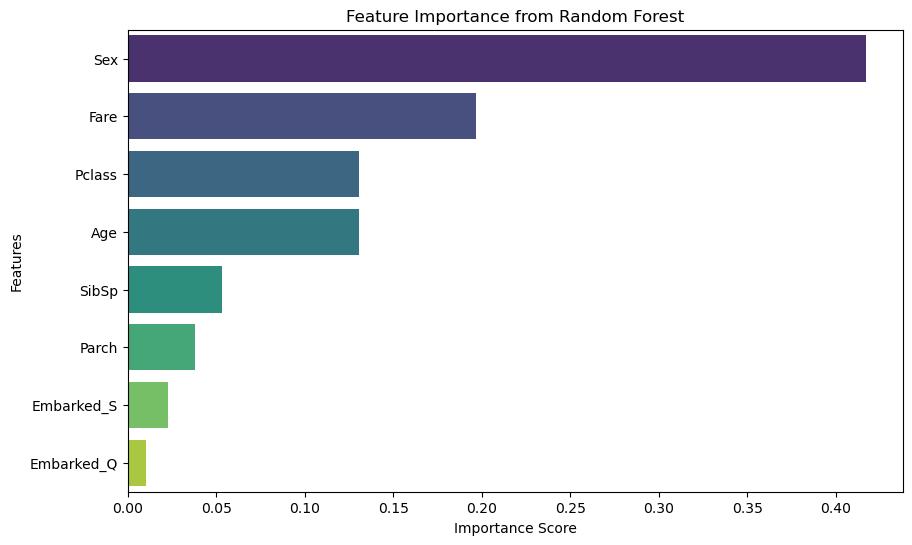

In [85]:
# Feature Importance Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Create a DataFrame for feature importance
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feature_importance, palette="viridis")
plt.title("Feature Importance from Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

Feature Importance Insights

Sex – Most important; females had a much higher survival chance.

Fare – Higher fare passengers survived more, reflecting class differences.

Pclass – First-class passengers had better survival rates.

Age – Children had slightly higher survival chances.

SibSp / Parch / Embarked – Less impact on survival.

Key takeaway: Gender, fare, and class were the main factors influencing survival.

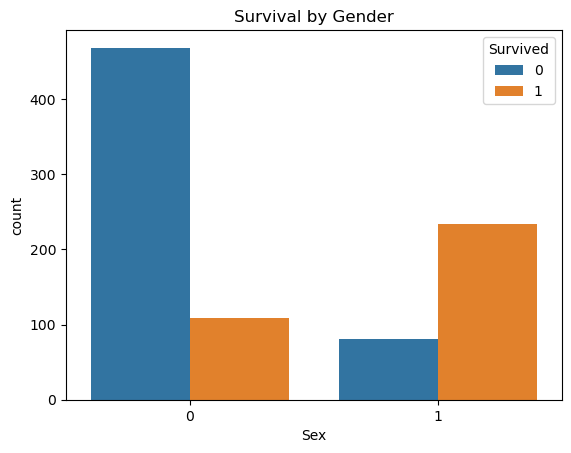

In [86]:
#Survival by Gender 
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Sex", hue="Survived", data=df)

plt.title("Survival by Gender")
plt.show()

Insight: Survival by Gender

The visualization shows a significant difference in survival rates between male and female passengers.

A large proportion of female passengers survived, while the majority of male passengers did not survive. This pattern strongly reflects the historical evacuation policy followed during the disaster, often described as “women and children first.”

This observation is also supported by the feature importance analysis from the Random Forest model, where Sex was the most important feature (importance ≈ 0.41) in predicting survival in the Titanic Dataset.

This indicates that gender played the most influential role in determining survival probability, which aligns with the historical context of the disaster. 

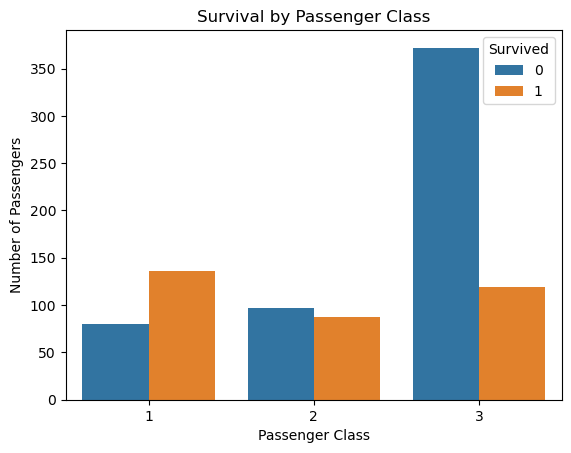

In [87]:
#Survival by Passenger Class
sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Number of Passengers")

plt.show()

Insight: Survival by Passenger Class

The visualization shows that passengers in higher classes had a greater chance of survival.

Passengers in 1st class had the highest survival rate, while 3rd class passengers had the lowest survival rate.
This may be due to several factors:

Better cabin locations closer to lifeboats

Higher priority during evacuation

Faster access to the ship's upper decks

This pattern suggests that socioeconomic status influenced survival chances during the disaster.

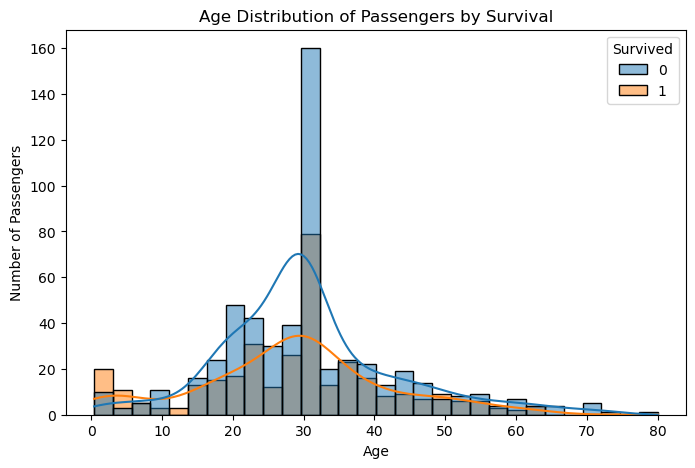

In [88]:
#Age Distribution of Passengers by Survival
plt.figure(figsize=(8,5))

sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)

plt.title("Age Distribution of Passengers by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

Insight: Age Distribution

You may observe that children had relatively higher survival rates, which aligns with the evacuation policy of “women and children first.”

Adults and older passengers had comparatively lower survival probabilities.

### Model Comparison

Two machine learning models were trained and evaluated in this project.

Decision Tree Accuracy: **0.78**

Random Forest Accuracy: **0.81**

The Random Forest model performed better than the Decision Tree.

This is because Random Forest combines multiple decision trees and reduces overfitting, which improves the model's ability to generalize to unseen data.

### Conclusion ###

**Key Insights from the Analysis**

Several important insights were discovered during the analysis of the Titanic dataset.

1. Gender was the most influential factor affecting survival.
   Female passengers had significantly higher survival rates than male passengers.

2. Passenger class strongly influenced survival probability.
   First-class passengers had the highest survival rates, while third-class passengers had the lowest.

3. Ticket fare showed a noticeable relationship with survival.
   Passengers who paid higher fares were more likely to survive.

4. Age had a moderate impact on survival.
   Children tended to have higher survival rates compared to many adult passengers.

These insights highlight how demographic and socioeconomic factors played an important role during the Titanic disaster.